# Température par heure pour les 15 derniers jours

Une courbe est tracée pour chaque date afin de comparer les températures chaque heure de la journée.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

CSV_FILE = r"Y:\Documents\temp03062024.csv"
DATA_START = pd.Timestamp("2024-04-21 13:00:00")
DAYS_TO_PLOT = 15

data = pd.read_csv(CSV_FILE)
if "temp" not in data.columns:
    raise ValueError("The CSV file must contain a temp column.")

# The CSV has one temperature measurement per hour.
data["timestamp"] = pd.date_range(DATA_START, periods=len(data), freq="h")
today = min(pd.Timestamp.now().floor("h"), data["timestamp"].iloc[-1])
start = today - pd.Timedelta(days=DAYS_TO_PLOT)
last_15_days = data.loc[data["timestamp"].between(start, today)].copy()

# Use exactly the 15 latest calendar dates.
last_15_days["day"] = last_15_days["timestamp"].dt.date
days_to_show = last_15_days["day"].drop_duplicates().tail(DAYS_TO_PLOT)
last_15_days = last_15_days[last_15_days["day"].isin(days_to_show)].copy()
last_15_days["hour"] = last_15_days["timestamp"].dt.hour

if last_15_days["day"].nunique() != DAYS_TO_PLOT:
    raise ValueError("Fewer than 15 days of temperature data are available.")


In [2]:
last_15_days


,temp,timestamp,day,hour
19907,29.39,2026-07-30 00:00:00,2026-07-30,0
19908,25.85,2026-07-30 01:00:00,2026-07-30,1
19909,25.00,2026-07-30 02:00:00,2026-07-30,2
19910,23.88,2026-07-30 03:00:00,2026-07-30,3
19911,23.32,2026-07-30 04:00:00,2026-07-30,4
...,...,...,...,...
20254,28.45,2026-08-13 11:00:00,2026-08-13,11
20255,31.26,2026-08-13 12:00:00,2026-08-13,12
20256,33.75,2026-08-13 13:00:00,2026-08-13,13
20257,35.31,2026-08-13 14:00:00,2026-08-13,14


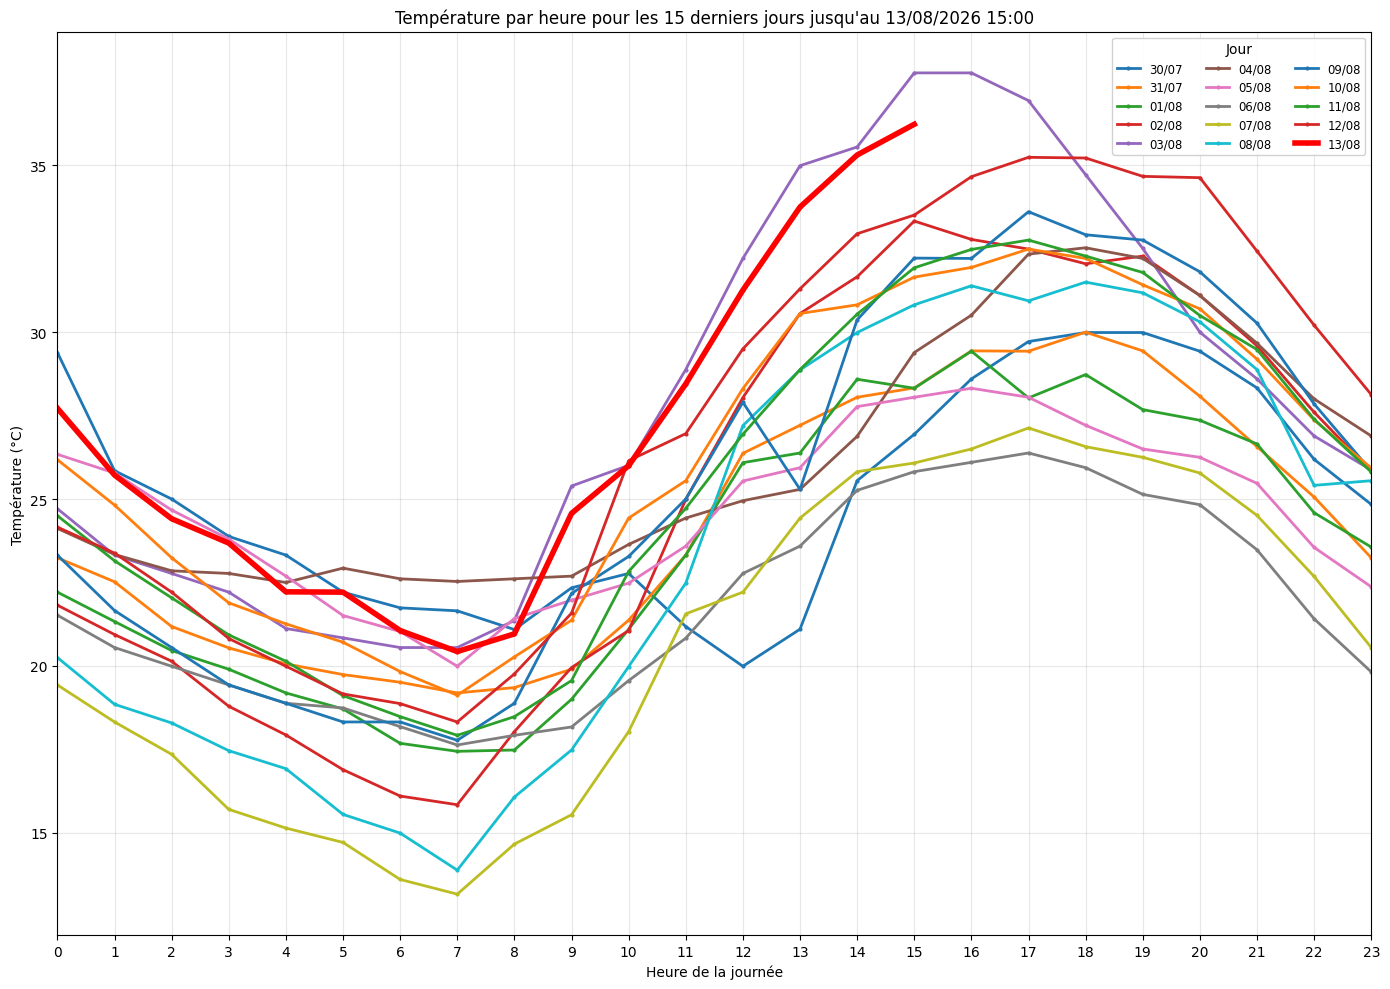

In [3]:
fig, ax = plt.subplots(figsize=(14, 10))
linewidth =2
color=None
for day, day_data in last_15_days.groupby("day", sort=True):
    if day == today.date(): 
        linewidth = 4
        color = 'red'
    ax.plot(
        day_data["hour"],
        day_data["temp"],
        marker="o",
        markersize=2,
        linewidth=linewidth, 
        color=color,  
        label=day.strftime("%d/%m")
    )

ax.set_title(f"Température par heure pour les 15 derniers jours jusqu'au {today:%d/%m/%Y %H:%M}")
ax.set_xlabel("Heure de la journée")
ax.set_ylabel("Température (°C)")
ax.set_xticks(range(24))
ax.set_xlim(0, 23)
ax.grid(True, alpha=0.3)
ax.legend(title="Jour", fontsize="small", ncol=3, framealpha=0.9)
plt.tight_layout()
plt.show()
